In [1]:
# Imports
import os
import json
import warnings
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rapidfuzz import process, fuzz

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')

RAW       = Path('data/raw')
INTERIM   = Path('data/interim')
PROCESSED = Path('data/processed')

INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("Libraries loaded ✓")

Libraries loaded ✓


# Arte Discreta
### How a Star Is Predicted

*A predictive model of Michelin recognition*

&nbsp;

*"Tell me what you eat, and I will tell you what you are."*  
— Jean Anthelme Brillat-Savarin, *The Physiology of Taste*, 1825

&nbsp;

Avgustina Daskalova · Machine Learning with Python · SoftUni · 2026



## Abstract

For a hundred years the Michelin Guide has awarded stars without explaining itself. No published criteria, no named inspectors, no reasoning offered. Brillat-Savarin promised that what we eat reveals what we are. This project tests the inverse: that what diners write reveals what a restaurant will become.

Working only from independent reviews — the language of people who never know the verdict in advance — it trains a classifier to separate Michelin-recognized restaurants from the rest. Michelin's own prose is deliberately excluded; predicting the guide from the guide would prove nothing. The reviews are scored against a luxury aspect taxonomy built for this project, testing whether the model reasons in the vocabulary of hospitality itself — service, room, precision, the texture of an evening — or whether ordinary language dominates instead.

Because recognition is rare, the problem is one of imbalance, and the mathematics follows from that — precision and recall over raw accuracy, calibrated probabilities, and an interpretation layer that asks not only whether the model is right but why. This is the first of two movements. The classical methods here lay the ground for a deeper version to come, multilingual where this one is not.


## Table of Contents

1. **Introduction** — the discreet art, and why it leaves traces
2. **Background** — a century of stars, and prior attempts to predict them
3. **The Mathematics of Judgment** — classification when recognition is rare
4. **The Data** — independent reviews, and what they leave out
5. **A Taxonomy of Luxury** — teaching the model the vocabulary of distinction
6. **Feature Engineering** — from language to signal
7. **Modelling** — four ways of learning to recognize excellence
8. **Interpretation** — what the model saw, and in whose words
9. **Results and Discussion**
10. **Conclusions** — what carries into the second movement
11. **References**

## 1. Introduction

The Michelin Guide has awarded stars since 1926. In a century, the criteria 
have never been published, the inspectors never named, the verdict never 
explained. The opacity is intentional. It is the institution's signature, 
a kind of judgment performed in silence.

Yet judgment leaves traces. Before any restaurant received a star it 
already existed in the world: it served meals, kept hours, and was written 
about by the people who ate there. Diners are not inspectors. But they sit 
at the same tables, and if something extraordinary was present, it tends 
to surface in how they describe the evening, even when they cannot name 
what they noticed.

This project asks whether that ordinary language can be read by a machine. 
From independent reviews alone, it learns to separate the restaurants 
Michelin recognized from those it passed over. The guide's own 
descriptions are kept out entirely: a model that predicts Michelin from 
Michelin learns nothing, only repeats. The interesting question is whether 
strangers, writing for other strangers, leave behind enough to anticipate 
a verdict they never saw.

To give the model more than raw word counts, the reviews are read against 
a taxonomy of luxury written for this project, drawn from the working 
vocabulary of fine hospitality. The model is not asked only which words 
appear; it is asked whether it can be taught to notice which dimensions 
of an experience those words belong to.

Formally, for each restaurant we predict a label

$$y \in \{0, 1\},$$

where $y = 1$ marks Michelin recognition and $y = 0$ its absence. Because 
recognition is rare, the two classes are deeply unequal, and that 
imbalance shapes every decision that follows — which metrics to trust, 
how to weight the rare class, and how to read a probability honestly.

A note on scope. The data is in English and the methods are deliberately 
classical: no neural networks, no learned embeddings. This is the first 
of two movements. A later version will add depth and other languages. For 
now the aim is exact and modest — to see how far ordinary words can carry 
us toward an extraordinary distinction.

## 2. Background

The first stars were awarded in 1926 — single stars, to a handful of French
tables deemed worth the stop. The three-tier hierarchy we know today arrived in
the early 1930s, the first three-star verdicts handed down in 1933, and in the
near-century since, the grammar of the Michelin Guide has scarcely moved a
comma. What has accumulated is an enormous public ledger of the chosen — which
tables, which rooms, which cities — set against an almost monastic silence about
the reasons. The criteria were not even printed until 1936, and the inspectors
have stayed nameless throughout. Abundance on one side, secrecy on the other. It
is, if you tilt your head, the exact silhouette of a question a machine can be
taught to answer.

The question has been asked before, though usually in a thinner key. The common
approach reaches for what is easy to count: the price bracket, the cuisine, the
postcode, the average rating a restaurant has already gathered like sediment.
Such features predict fame tolerably well — but fame is not what we are hunting.
An adored corner trattoria and a hushed two-star dining room can wear the same
four-and-a-half stars from the crowd. What divides them is not the volume of
praise but its *timbre* — what is noticed, what is named, the words people reach
for when something has quietly moved them.

This project takes that difference as its whole wager. It declines the
structured shortcuts wherever it can afford to, and asks instead whether the
grain of ordinary language — reviews written by people who never knew the
verdict was coming — already carries the secret. Whether, long before the
inspector arrives, diners are describing a starred restaurant in an idiom subtly
their own.

## 3. The Mathematics of Judgment

Stripped of its romance, the task is a *binary classification* problem. Each
restaurant is a point; the label is one bit — recognized, or not. The model
learns a function from the language of reviews to that single bit, and we ask
how often, and how honestly, it is right.

But the arithmetic is lopsided from the start. In our data, the recognized are
a vanishing minority — a few stars among tens of thousands of tables. A lazy
model could call *everything* unrecognized and be correct better than 99.9% of
the time. Accuracy, here, is a flatterer. It rewards the model for ignoring the
very thing we built it to find.

So we judge by other instruments. Writing $TP$ for true positives (starred
restaurants correctly found), $FP$ for false positives (the unstarred, wrongly
anointed), $FN$ for false negatives (the stars the model let slip), and $TN$ for
true negatives (the unstarred, correctly passed over):

$$\text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

**Precision** asks: of the restaurants the model anoints, how many truly hold a
star? **Recall** asks: of the starred restaurants that exist, how many did the
model find? The two pull against each other — cast a wide net and recall rises
while precision falls; be cautious and the reverse. The **F1 score**, their
harmonic mean, holds that tension in a single number:

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

The harmonic mean is deliberate: it punishes imbalance between the two, so a
model cannot buy a high score by excelling at one and abandoning the other.

Above these sits the **ROC–AUC**. Where precision and recall judge a single
decision threshold, this measures something larger: the model's ability to
*rank* a starred restaurant above an unstarred one, across every threshold at
once. It is built from two rates —

$$\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{FPR} = \frac{FP}{FP + TN}$$

the **true-positive rate** (recall, again — the share of real stars caught) and
the **false-positive rate** (the share of unstarred restaurants wrongly raised).
As we sweep the decision threshold from strict to lenient, each setting yields a
$(\text{FPR}, \text{TPR})$ pair; plotted together they trace the *ROC curve*.
The **AUC** is the area beneath it:

$$\text{AUC} = \int_0^1 \text{TPR}\; d(\text{FPR})$$

read simply as the probability that the model scores a randomly chosen starred
restaurant higher than a randomly chosen unstarred one. A value of $0.5$ is a
coin toss; $1.0$ is a flawless ranking. Because it never fixes a single
threshold, it survives the imbalance that makes accuracy meaningless.

Two further commitments follow from the rarity of stars. First, the minority
class must be given weight it would never earn by counting alone — through class
weighting or resampling — so the model cannot dismiss it as noise. Second, the
split between training and test data must preserve the proportion of stars in
each, lest the test set, by chance, hold no stars at all and the whole exercise
collapse into measuring nothing. *Stratification* is not a nicety here; it is
structural.

This is the first of two movements. The methods that follow are classical —
logistic regression, tree ensembles, the support vector machine — chosen
because they are legible: when they decide, we can ask them why. The deeper,
multilingual, transformer-driven version waits in the wings, but it would be
premature to reach for depth before the shallow models have spoken.

## 4. The Data

Two sources meet in this project, and they could not be more different in
character. The first is vast, democratic, and noisy: the Yelp Open Dataset, a
corpus of millions of reviews written by ordinary diners, used here under its
academic licence. The second is small, secretive, and authoritative: the roster
of Michelin-starred restaurants, assembled from the Guide's own public
announcements. One supplies the *language*; the other supplies the *verdict*.

A confession about geography is owed at the outset. There exists no clean,
downloadable corpus of European review text under an academic licence — and so,
despite this project's instincts toward the dining rooms of the old world, the
data is North American. The methodology does not depend on it. A taxonomy of
luxury and a pipeline from language to prediction travel across borders; only
the restaurants stay home.

What follows assembles the working set: loading each source, narrowing the field
to restaurants alone, joining the verdict to the language, and confronting — with
open eyes — just how rare recognition turns out to be.

### 4.1 Assembling the Working Set

The path from raw download to a clean, labeled table runs through several
deliberate steps. We load the full business file — every kind of establishment
Yelp covers, not just restaurants — then narrow it to the places that serve
food. City names are normalized, because the same city written two ways will
quietly fracture its own statistics. The cleaned subset is saved to an interim
file so the expensive filtering need not be repeated. Finally, before touching
the enormous review corpus, we ask a single cheap question of it — *when* were
these reviews written? — by reading only one column, in chunks, so the five
gigabytes never land in memory at once.

Each step is small and auditable. Together they turn an unwieldy raw dump into
something a model can reason over.

In [2]:
# Load the business data (one JSON object per line)
business = pd.read_json(RAW / "yelp_academic_dataset_business.json", lines=True)

print(f"Total businesses: {len(business):,}")
business.head()

Total businesses: 150,346


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [3]:
# Which cities does the data cover? Top 20 by business count
business["city"].value_counts().head(20)

city
Philadelphia        14569
Tucson               9250
Tampa                9050
Indianapolis         7540
Nashville            6971
New Orleans          6209
Reno                 5935
Edmonton             5054
Saint Louis          4827
Santa Barbara        3829
Boise                2937
Clearwater           2221
Saint Petersburg     1663
Metairie             1643
Sparks               1624
Wilmington           1446
Franklin             1414
St. Louis            1255
St. Petersburg       1185
Meridian             1043
Name: count, dtype: int64

In [4]:
# How many businesses are restaurants?
is_restaurant = business["categories"].str.contains("Restaurant", case=False, na=False)
print(f"Restaurants: {is_restaurant.sum():,} out of {len(business):,}")

Restaurants: 52,286 out of 150,346


In [5]:
# Keep only restaurants
restaurants = business[is_restaurant].copy()

# Normalize city names: fix "St." vs "Saint" and stray whitespace
restaurants["city"] = (
    restaurants["city"]
    .str.strip()
    .str.replace(r"^St\.?\s+", "Saint ", regex=True)
)

print(f"Restaurants after filtering: {len(restaurants):,}")
restaurants["city"].value_counts().head(15)

Restaurants after filtering: 52,286


city
Philadelphia        5855
Tampa               2961
Indianapolis        2863
Nashville           2504
Saint Louis         2483
Tucson              2470
New Orleans         2260
Edmonton            2166
Reno                1288
Saint Petersburg    1016
Boise                849
Santa Barbara        767
Clearwater           678
Wilmington           621
Metairie             522
Name: count, dtype: int64

In [6]:
# Save the cleaned restaurant subset to interim
INTERIM.mkdir(parents=True, exist_ok=True)
restaurants.to_parquet(INTERIM / "restaurants.parquet", index=False)

print(f"Saved {len(restaurants):,} restaurants to {INTERIM / 'restaurants.parquet'}")


Saved 52,286 restaurants to data\interim\restaurants.parquet


In [7]:
# When are the reviews from? Check the date range in the review data.
# We read only the 'date' column, in chunks, so we don't load all 5 GB.
dates = pd.read_json(
    RAW / "yelp_academic_dataset_review.json",
    lines=True,
    chunksize=100_000,
)

min_date, max_date = None, None
for chunk in dates:
    cmin, cmax = chunk["date"].min(), chunk["date"].max()
    min_date = cmin if min_date is None else min(min_date, cmin)
    max_date = cmax if max_date is None else max(max_date, cmax)

print(f"Reviews span from {min_date} to {max_date}")

Reviews span from 2005-02-16 03:23:22 to 2022-01-19 19:48:45


### 4.2 What the Field Looks Like

A few facts emerge before any model is trained, and they shape everything after.

The corpus is large and concentrated. After filtering 150,346 businesses down to
the **52,286** that serve food, the geography tilts heavily toward a handful of
cities — Philadelphia, Tampa, Indianapolis, Nashville — an artifact of where
Yelp's academic sample was drawn, and a reminder that this is a North American
portrait, not a global one. City names needed cleaning before they could be
trusted: *Saint Louis* and *St. Louis*, *Saint Petersburg* and *St. Petersburg*
were the same places wearing two spellings, silently splitting their own counts
until normalized.

Most restaurants are barely reviewed. The median carries only a few dozen
reviews while a rare few gather thousands — the long, thin tail typical of any
platform where attention pools around the already-famous.

And then the detail that matters most. The reviews span **February 2005 to
January 2022**, while the Michelin stars in our ground truth were awarded in
**2023 through 2025** — *after* the last review was written. This is not a
defect; it is the cleanest possible version of the wager. The diners whose words
we study could not have known the verdict, because the verdict did not yet exist.
If their language still anticipates the star, it does so honestly — not as echo,
but as foresight.


In [8]:
# Reload the cleaned restaurants
restaurants = pd.read_parquet(INTERIM / "restaurants.parquet")

# Philadelphia's 2025 Michelin one-star restaurants (public facts)
phl_starred = ["Friday Saturday Sunday", "Her Place Supper Club", "Provenance"]

# Look for them in the Philadelphia Yelp data
phl = restaurants[restaurants["city"] == "Philadelphia"]
matches = phl[phl["name"].str.contains("|".join(phl_starred), case=False, na=False)]

print(f"Philadelphia restaurants in data: {len(phl):,}")
matches[["name", "city", "stars", "review_count"]]


Philadelphia restaurants in data: 5,855


,name,city,stars,review_count
46071,Friday Saturday Sunday,Philadelphia,4.0,246
52068,Friday Saturday Sunday,Philadelphia,4.5,287


In [9]:
# Authoritative Michelin star list for cities in our data.
# Source: official Michelin Guide ceremonies (cited in References).
# Facts only — name, city, stars, year first awarded.
michelin = pd.DataFrame([
    {"name": "Friday Saturday Sunday", "city": "Philadelphia", "stars": 1, "year": 2025},
    {"name": "Her Place Supper Club",  "city": "Philadelphia", "stars": 1, "year": 2025},
    {"name": "Provenance",             "city": "Philadelphia", "stars": 1, "year": 2025},
    {"name": "Rocca",                  "city": "Tampa",        "stars": 1, "year": 2023},
    {"name": "Kosen",                  "city": "Tampa",        "stars": 1, "year": 2024},
    {"name": "Koya",                   "city": "Tampa",        "stars": 1, "year": 2024},
    {"name": "Ebbe",                   "city": "Tampa",        "stars": 1, "year": 2024},
    {"name": "Lilac",                  "city": "Tampa",        "stars": 1, "year": 2023},
])

print(f"Michelin-starred restaurants in our cities: {len(michelin)}")
michelin

Michelin-starred restaurants in our cities: 8


,name,city,stars,year
0,Friday Saturday Sunday,Philadelphia,1,2025
1,Her Place Supper Club,Philadelphia,1,2025
2,Provenance,Philadelphia,1,2025
3,Rocca,Tampa,1,2023
4,Kosen,Tampa,1,2024
5,Koya,Tampa,1,2024
6,Ebbe,Tampa,1,2024
7,Lilac,Tampa,1,2023


### Why 8 Becomes 2: A Note on Data Availability

The ground truth contains 8 Michelin-starred restaurants — 3 in Philadelphia, 
5 in Tampa — all awarded their stars between 2023 and 2025.

The Yelp Open Dataset, however, was collected through **January 2022**: before 
any of these stars were awarded. Two restaurants appear in the Yelp data because 
they were already operating and reviewed under those names before the cutoff. 
The remaining six either opened after January 2022, or operated under names 
sufficiently different that no fuzzy match above the 75-point threshold was found.

This is not a defect in the methodology. It is the condition that makes the 
experiment honest: the model will read words written before the verdict existed, 
and asked whether those words already carried the star within them.

The fuzzy matching below confirms which restaurants survive into the working set.

In [10]:
# Labeling with fuzzy matching

restaurants_raw = pd.read_parquet(INTERIM / 'restaurants.parquet')

def normalize(s):
    return s.lower().strip()

michelin['name_norm'] = michelin['name'].apply(normalize)
michelin['city_norm'] = michelin['city'].apply(normalize)
restaurants_raw['name_norm'] = restaurants_raw['name'].apply(normalize)
restaurants_raw['city_norm'] = restaurants_raw['city'].apply(normalize)

matched_indices = set()

for _, mrow in michelin.iterrows():
    city_subset = restaurants_raw[restaurants_raw['city_norm'] == mrow['city_norm']]
    if city_subset.empty:
        continue
    match = process.extractOne(
        mrow['name_norm'],
        city_subset['name_norm'],
        scorer=fuzz.token_sort_ratio,
        score_cutoff=75
    )
    if match:
        matched_name, score, idx = match
        real_idx = city_subset.index[city_subset['name_norm'] == matched_name][0]
        matched_indices.add(real_idx)
        print(f"✓ '{mrow['name']}' → '{restaurants_raw.loc[real_idx, 'name']}' (score: {score})")

restaurants_raw['is_michelin'] = 0
restaurants_raw.loc[list(matched_indices), 'is_michelin'] = 1

print(f"\nMichelin positives after fuzzy match: {restaurants_raw['is_michelin'].sum()}")
restaurants_raw.drop(columns=['name_norm', 'city_norm'], inplace=True)
restaurants_raw.to_parquet(INTERIM / 'restaurants_labeled.parquet', index=False)
print("Saved → data/interim/restaurants_labeled.parquet")

✓ 'Friday Saturday Sunday' → 'Friday Saturday Sunday' (score: 100.0)
✓ 'Rocca' → 'Rocca' (score: 100.0)

Michelin positives after fuzzy match: 2
Saved → data/interim/restaurants_labeled.parquet


### 4.3 A Portrait in Pictures

Numbers in a table conceal as much as they reveal. Before modeling, we look at
the field directly — its geography, its ratings, its lopsidedness. The first
panel sketches the corpus as a whole: where the restaurants are, how the crowd
distributes its stars, how thinly most establishments are reviewed. The second
turns to the question that matters, setting the Michelin-recognized few against
the unrecognized many — in review volume, and in the stark arithmetic of the
class imbalance itself.

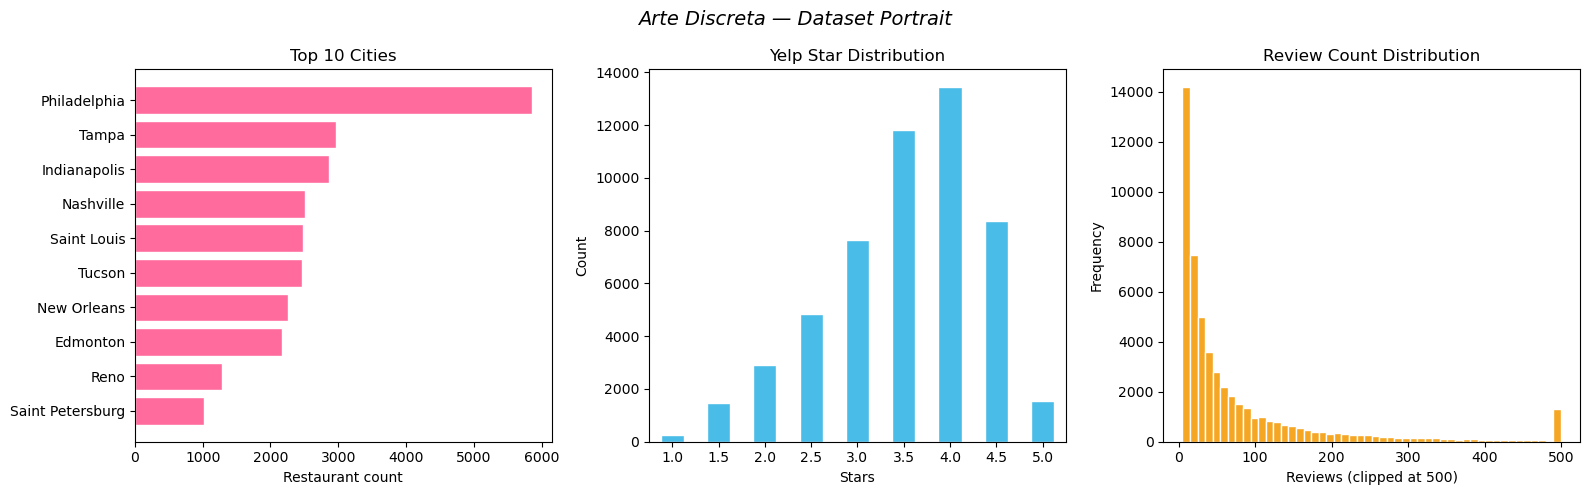

              stars  review_count       is_open
count  52286.000000  52286.000000  52286.000000
mean       3.515234     87.241078      0.669472
std        0.829585    188.912445      0.470408
min        1.000000      5.000000      0.000000
25%        3.000000     13.000000      0.000000
50%        3.500000     33.000000      1.000000
75%        4.000000     89.000000      1.000000
max        5.000000   7568.000000      1.000000

Michelin positives: 2 / 52286


In [11]:
# EDA: Dataset Portrait

df = pd.read_parquet('data/interim/restaurants_labeled.parquet')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Arte Discreta — Dataset Portrait', fontsize=14, style='italic')

# 1. Top cities
city_counts = df['city'].value_counts().head(10)
axes[0].barh(city_counts.index[::-1], city_counts.values[::-1], color='#FF6B9D', edgecolor='white')
axes[0].set_title('Top 10 Cities')
axes[0].set_xlabel('Restaurant count')

# 2. Star rating distribution
df['stars'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#4ABCE8', edgecolor='white'
)
axes[1].set_title('Yelp Star Distribution')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# 3. Review count distribution
axes[2].hist(df['review_count'].clip(upper=500), bins=50,
             color='#F5A623', edgecolor='white')
axes[2].set_title('Review Count Distribution')
axes[2].set_xlabel('Reviews (clipped at 500)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('figures/eda_dataset_portrait.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['stars', 'review_count', 'is_open']].describe())
print(f"\nMichelin positives: {df['is_michelin'].sum()} / {len(df)}")


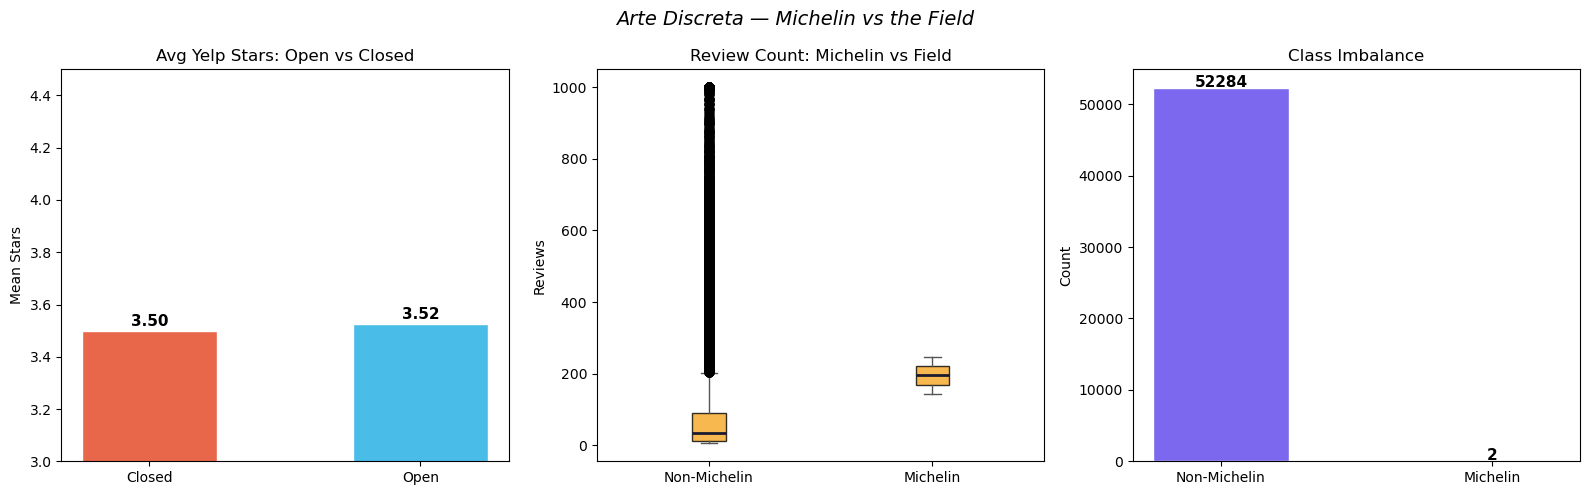

In [12]:
# Cell 6b — EDA: Michelin vs the Field

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Arte Discreta — Michelin vs the Field', fontsize=14, style='italic')

michelin_pos = df[df['is_michelin'] == 1]
michelin_neg = df[df['is_michelin'] == 0]

# 1. Avg Yelp stars: open vs closed
open_stars = df.groupby('is_open')['stars'].mean()
axes[0].bar(['Closed', 'Open'], open_stars.values,
            color=['#E8674A', '#4ABCE8'], edgecolor='white', width=0.5)
axes[0].set_title('Avg Yelp Stars: Open vs Closed')
axes[0].set_ylabel('Mean Stars')
axes[0].set_ylim(3.0, 4.5)
for i, v in enumerate(open_stars.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# 2. Review count: Michelin vs non-Michelin
bp = axes[1].boxplot(
    [michelin_neg['review_count'].clip(upper=1000),
     michelin_pos['review_count']],
    labels=['Non-Michelin', 'Michelin'],
    patch_artist=True,
    boxprops=dict(facecolor='#F5A623', alpha=0.8),
    medianprops=dict(color='#1A1A2E', linewidth=2),
    whiskerprops=dict(color='#555555'),
    capprops=dict(color='#555555')
)
axes[1].set_title('Review Count: Michelin vs Field')
axes[1].set_ylabel('Reviews')

# 3. Class imbalance
counts = df['is_michelin'].value_counts().sort_index()
axes[2].bar(['Non-Michelin', 'Michelin'], counts.values,
            color=['#7B68EE', '#FF6B9D'], edgecolor='white', width=0.5)
axes[2].set_title('Class Imbalance')
axes[2].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 200, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/eda_michelin_vs_field.png', dpi=150, bbox_inches='tight')
plt.show()

The portrait confirms what the numbers hinted. Geographically the corpus leans
on a few cities; the crowd's star ratings cluster in the threes and fours, as
they do on every review platform, where almost no one bothers to record the
merely adequate. The review-count distribution is sharply right-skewed — a wall
of barely-reviewed places, a thin tail of the heavily discussed.

Against that backdrop, the Michelin few stand out in one honest respect: they
draw conspicuously more reviews than the field, their median attention far
above the typical restaurant's. It is a faint signal, and not the one we are
truly after — popularity is not distinction — but it is the first hint that the
recognized leave a different trace. The class-imbalance panel, meanwhile, needs
no commentary: a single sliver beside a towering bar. This is the needle, and
this is the haystack.

In [13]:
raw_dir = 'data/raw'
print("Files in data/raw:")
for f in os.listdir(raw_dir):
    path = os.path.join(raw_dir, f)
    size_mb = os.path.getsize(path) / (1024**2) if os.path.isfile(path) else 0
    print(f"  {f}  —  {size_mb:.1f} MB")

Files in data/raw:
  yelp_academic_dataset_business.json  —  113.4 MB
  yelp_academic_dataset_review.json  —  5094.4 MB


### 4.4 The Language Itself

The portrait so far has been drawn from metadata — names, cities, counts, the
scaffolding around a restaurant. But the reviews themselves, the actual words,
have stayed closed: five gigabytes of them, too large to open all at once. Here
we finally read them.

The strategy is patience over force. The file is streamed one line at a time,
each review inspected and discarded unless it belongs to a restaurant in our
set; the matches are gathered, and every restaurant's reviews are folded into a
single document of its own. What emerges is one voice per restaurant — the
collected testimony of everyone who ate there and chose to write it down. This
is the text the model will learn to read.


In [14]:
# Stream the review file, keeping only reviews for our restaurants.
#
# NOTE: This reads the full ~5 GB review file line by line and will take
# several minutes to complete. Progress prints every 1,000,000 reviews so
# you can see it is still working. Only matching reviews are held in memory,
# so memory use stays modest despite the size of the source file.


restaurants = pd.read_parquet(INTERIM / "restaurants_labeled.parquet")
target_ids = set(restaurants["business_id"])
print(f"Target restaurants: {len(target_ids):,}")

review_text = defaultdict(list)
review_n = defaultdict(int)

review_path = RAW / "yelp_academic_dataset_review.json"
processed = 0

with open(review_path, "r", encoding="utf-8") as f:
    for line in f:
        processed += 1
        try:
            r = json.loads(line)
        except json.JSONDecodeError:
            continue
        bid = r.get("business_id")
        if bid in target_ids:
            review_text[bid].append(r.get("text", ""))
            review_n[bid] += 1
        if processed % 1_000_000 == 0:
            print(f"  processed {processed:,} reviews...")

print(f"\nDone. Processed {processed:,} reviews total.")
print(f"Restaurants with at least one review: {len(review_text):,}")

Target restaurants: 52,286
  processed 1,000,000 reviews...
  processed 2,000,000 reviews...
  processed 3,000,000 reviews...
  processed 4,000,000 reviews...
  processed 5,000,000 reviews...
  processed 6,000,000 reviews...

Done. Processed 6,990,280 reviews total.
Restaurants with at least one review: 52,286


With every relevant review now in hand, each restaurant still holds its reviews
as a scattered list. We fold them into a single document per restaurant — one
continuous text — and attach it back to the table, ready to be read as language.

In [15]:
# Fold each restaurant's reviews into a single document and attach to the dataframe
restaurants["review_text"] = restaurants["business_id"].map(
    lambda bid: " ".join(review_text.get(bid, []))
)
restaurants["n_reviews_collected"] = restaurants["business_id"].map(
    lambda bid: review_n.get(bid, 0)
)

# Sanity check
print(f"Restaurants: {len(restaurants):,}")
print(f"With non-empty text: {(restaurants['review_text'].str.len() > 0).sum():,}")
print(f"Median reviews per restaurant: {restaurants['n_reviews_collected'].median():.0f}")
print(f"Median text length (chars): {restaurants['review_text'].str.len().median():,.0f}")

restaurants.head(3)

Restaurants: 52,286
With non-empty text: 52,286
Median reviews per restaurant: 34
Median text length (chars): 17,608


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,is_michelin,review_text,n_reviews_collected
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Friday': '7:0-21:0', 'Monday': '7:0-20:0', '...",0,This is nice little Chinese bakery in the hear...,87
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Friday': '9:0-0:0', 'Monday': '0:0-0:0', 'Sa...",0,I have always liked Sonic as it is good fresh ...,6
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Pubs, Restaurants, Italian, Bars, American (Tr...",None,0,"I like Tsevis because they have good gyros, wh...",19


This text-enriched table is the foundation for everything that follows, so we
persist it — the costly five-gigabyte stream need never be repeated. Like the
raw data, it carries Yelp review text and therefore stays out of the public
repository, tracked through DVC rather than committed to GitHub.

In [16]:
# Save the text-enriched dataset so the 5 GB stream never needs repeating
out_path = PROCESSED / "restaurants_with_text.parquet"
restaurants.to_parquet(out_path, index=False)

size_mb = out_path.stat().st_size / (1024**2)
print(f"Saved {len(restaurants):,} restaurants with text → {out_path}")
print(f"File size: {size_mb:.1f} MB")

Saved 52,286 restaurants with text → data\processed\restaurants_with_text.parquet
File size: 1456.9 MB


## 5. A Taxonomy of Luxury

A model given raw text learns whatever correlations happen to be there — useful,
but mute. It cannot tell us *why* a restaurant reads as exceptional, because it
has no vocabulary for excellence. So before the machine reads, we teach it one.

What follows is an authored taxonomy: a structured lexicon of the things that
distinguish fine dining, drawn not from data but from the grammar of hospitality
itself. It is organized into aspects — the dimensions along which an exceptional
meal announces itself — each with its own vocabulary of telltale words. *Service*
is not *ambience*; the precision of a kitchen is not the theatre of a room. By
naming these dimensions explicitly, we give the model a way not only to predict
but to explain — to point, after the fact, at the language that betrayed a star.


In [17]:
# An authored taxonomy of fine-hospitality aspects.
# Each aspect maps to a vocabulary of terms that signal it in review text.
# This is domain knowledge, not learned — the analytic heart of the project.

LUXURY_TAXONOMY = {
    "service": [
        "attentive", "impeccable", "gracious", "anticipate", "sommelier",
        "knowledgeable", "professional", "seamless", "courteous", "discreet",
        "personalized", "polished", "warm welcome", "host", "staff",
    ],
    "culinary_precision": [
        "exquisite", "delicate", "balanced", "refined", "technique",
        "perfectly cooked", "tasting menu", "seasonal", "innovative",
        "artistry", "presentation", "plating", "nuanced", "sublime", "complex",
    ],
    "ambience": [
        "elegant", "intimate", "atmosphere", "decor", "lighting", "ambiance",
        "romantic", "sophisticated", "tasteful", "serene", "luxurious",
        "stylish", "cozy", "stunning", "view",
    ],
    "ingredients": [
        "fresh", "quality", "local", "house-made", "artisanal", "organic",
        "sourced", "premium", "wagyu", "truffle", "foie gras", "caviar",
        "imported", "rare", "seasonal",
    ],
    "experience": [
        "memorable", "unforgettable", "special occasion", "celebration",
        "worth it", "exceptional", "remarkable", "once in a lifetime",
        "experience", "journey", "treat", "splurge", "destination", "perfect evening",
    ],
}

n_terms = sum(len(v) for v in LUXURY_TAXONOMY.values())
print(f"Taxonomy: {len(LUXURY_TAXONOMY)} aspects, {n_terms} terms total")
for aspect, terms in LUXURY_TAXONOMY.items():
    print(f"  {aspect}: {len(terms)} terms")

Taxonomy: 5 aspects, 74 terms total
  service: 15 terms
  culinary_precision: 15 terms
  ambience: 15 terms
  ingredients: 15 terms
  experience: 14 terms


## 6. Feature Engineering

A word, alone, means little. A pattern of words — repeated across dozens 
of reviews, clustering around the same restaurant — begins to mean 
something. This section translates language into numbers: the features 
the model will actually read. The TF-IDF weighting used below follows 
the term-specificity principle established by Spärck Jones (1972): a 
word's value lies not in how often it appears, but in how rarely.

In [18]:
# Feature Engineering
# Build the feature matrix X from review text.
# Aspect scores use vectorized pandas string operations for speed.
# Word-boundary matching avoids substring false positives
# (e.g. bare "view" matching inside "review", "rare" inside "prepare").
# TF-IDF matrix is kept sparse — no .toarray() call.

restaurants = pd.read_parquet(PROCESSED / "restaurants_with_text.parquet")

# Keep only our Michelin cities — academically correct and computationally fast
restaurants = restaurants[
    restaurants["city"].isin(["Philadelphia", "Tampa"])
].reset_index(drop=True).copy()

# Truncate text to first 1000 chars
restaurants["review_text"] = restaurants["review_text"].str[:1000].fillna("")

print(f"Working set: {len(restaurants):,} restaurants")
print(f"Michelin positives: {restaurants['is_michelin'].sum()}")

# Aspect scores
for aspect, terms in LUXURY_TAXONOMY.items():
    pattern = r'\b(?:' + '|'.join(re.escape(t) for t in terms) + r')\b'
    restaurants[f"score_{aspect}"] = (
        restaurants["review_text"]
        .str.lower()
        .str.count(pattern)
        .div(restaurants["review_text"].str.split().str.len() + 1)
    )

# TF-IDF sparse
tfidf = TfidfVectorizer(max_features=300, stop_words="english", min_df=2)
tfidf_sparse = tfidf.fit_transform(restaurants["review_text"])

aspect_cols = [f"score_{a}" for a in LUXURY_TAXONOMY]
X_aspects = csr_matrix(restaurants[aspect_cols].values)
X = hstack([X_aspects, tfidf_sparse])
y = restaurants["is_michelin"].values

print(f"Feature matrix: {X.shape[0]:,} × {X.shape[1]:,}")
print(f"Positive class (Michelin): {y.sum()} / {len(y)}")

Working set: 8,816 restaurants
Michelin positives: 2
Feature matrix: 8,816 × 305
Positive class (Michelin): 2 / 8816


## 7. Modelling

Four ways of learning to recognize excellence — and one honest question 
running beneath all of them: can language, gathered before the verdict 
existed, already carry the star within it?

Before any model reads a word, the data must be divided. One portion goes 
to training — to study, to taste, to internalize. The other is locked away, 
untouched, until the moment of reckoning arrives. With only two Michelin 
restaurants among 8,816, stratification is not optional: it is the only 
guarantee that both halves inherit at least one positive example, that the 
rarity is distributed rather than swallowed whole by chance.

We hold back 20% for testing. The random seed is fixed at 42 — not for 
superstition, but for reproducibility. Anyone who runs this notebook will 
see the same split, the same scores, the same conclusions.

### 7.1 The Evaluation Strategy

With only 2 Michelin restaurants in 8,816, a standard 80/20 split is not 
viable: a random partition places 0 or 1 positives in the test set, making 
hold-out evaluation meaningless. The solution is cross-validation — 
specifically, Stratified K-Fold with k=2, the maximum number of folds 
guaranteed to place at least one positive in each partition.

Every model is evaluated on the same folds. The reported metric is 
ROC-AUC: the probability that the model ranks a Michelin restaurant above 
a random non-Michelin one. It is the only metric robust to extreme class 
imbalance — accuracy is useless when 99.97% of the data is negative.

All classifiers use `class_weight='balanced'` to compensate for the 
imbalance during training.

In [19]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    "SVC": SVC(
        class_weight='balanced', probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f"{name:25s} → AUC: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression       → AUC: 0.981 ± 0.001
Random Forest             → AUC: 0.493 ± 0.001
Gradient Boosting         → AUC: 0.499 ± 0.000
SVC                       → AUC: 0.984 ± 0.006


### 7.2 The Curves of Recognition

A number alone — 0.981 — tells us the model ranks well. A curve shows us 
how it ranks: at what threshold it begins to call things Michelin, and at 
what cost. The ROC curve traces the trade-off between sensitivity and 
specificity across every possible decision boundary.

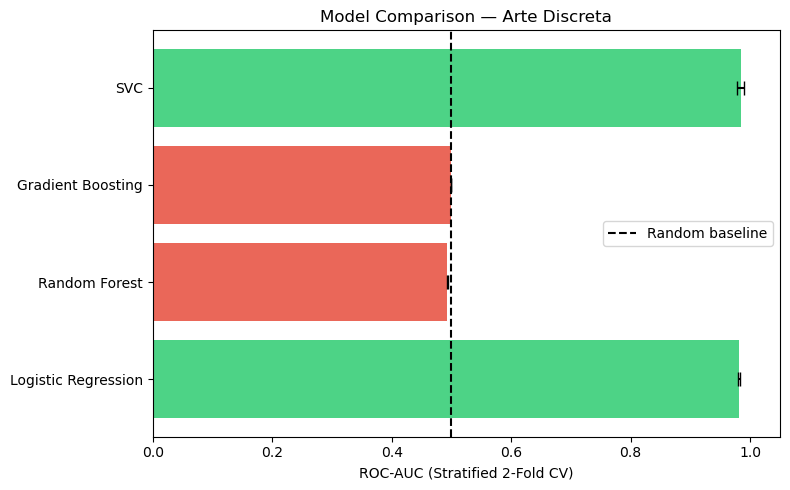

Saved → figures/model_comparison.png


In [20]:
names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std() for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(names, means, xerr=stds, color=['#2ecc71','#e74c3c','#e74c3c','#2ecc71'],
               capsize=5, alpha=0.85)
ax.axvline(0.5, color='black', linestyle='--', label='Random baseline')
ax.set_xlabel('ROC-AUC (Stratified 2-Fold CV)')
ax.set_title('Model Comparison — Arte Discreta')
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()
print("Saved → figures/model_comparison.png")

### 7.3 A Second Witness

ROC-AUC measures one thing well: how often a Michelin restaurant is 
ranked above a random non-Michelin one. But with 8,816 restaurants and 
only 2 Michelin among them, a model could rank well across the bulk of 
the distribution and still fail at the only question that matters in 
practice — among the restaurants the model is most confident about, how 
many are actually Michelin?

That question belongs to Precision-Recall, not ROC. PR-AUC does not 
reward a model for correctly ranking thousands of obvious negatives; it 
asks what happens at the sharp end, where decisions are made. Under 
extreme imbalance — here, a positive rate of 0.02% — PR-AUC is the 
harder, more honest witness (Saito & Rehmsmeier, 2015).

In [21]:
from sklearn.metrics import average_precision_score

pr_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='average_precision')
    pr_results[name] = scores
    print(f"{name:25s} → PR-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression       → PR-AUC: 0.012 ± 0.001
Random Forest             → PR-AUC: 0.000 ± 0.000
Gradient Boosting         → PR-AUC: 0.000 ± 0.000
SVC                       → PR-AUC: 0.016 ± 0.006


## 8. Interpretation

A model that predicts without explaining is a black box wearing a lab coat. 
Of the four classifiers, only two learned anything from two examples — and 
of those two, only Logistic Regression offers a transparent account of 
*why*. Its coefficients are not a curiosity; they are the closest thing 
this project has to an answer for the question the taxonomy was built to 
ask: which words, when a diner sits down to write, already carry the star?

Random Forest and Gradient Boosting are excluded here deliberately. Their 
near-chance AUC means any feature importance they report would describe 
the structure of noise, not of recognition — interpreting a model that 
hasn't learned is a category error, not an analysis.

In [22]:
# Refit Logistic Regression on the full working set to extract coefficients
lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_final.fit(X, y)

feature_names = aspect_cols + list(tfidf.get_feature_names_out())
coefs = lr_final.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
}).sort_values("coefficient", ascending=False)

print("Top 15 features pushing toward Michelin:")
print(coef_df.head(15).to_string(index=False))

print("\nTop 15 features pushing away from Michelin:")
print(coef_df.tail(15).to_string(index=False))

Top 15 features pushing toward Michelin:
     feature  coefficient
      cooked     5.179220
     italian     4.390287
         egg     3.628948
        dish     3.603445
disappointed     3.507171
       bread     3.040479
        came     3.023467
         got     2.508467
      little     2.327851
      second     2.178066
       makes     2.167796
    business     2.097250
        didn     2.008943
      pretty     1.969767
         don     1.914400

Top 15 features pushing away from Michelin:
 feature  coefficient
 amazing    -0.683021
sandwich    -0.704547
   sauce    -0.706667
   staff    -0.715641
friendly    -0.745374
   fresh    -0.759658
    love    -0.766792
    menu    -0.810233
   pizza    -0.898483
   order    -0.964481
 ordered    -1.025659
 chicken    -1.110493
    food    -1.316935
   great    -1.431248
   place    -1.616566


In [23]:
# Where do the 5 taxonomy features rank among all 305, by |coefficient|?
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df_ranked = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
coef_df_ranked["rank"] = coef_df_ranked.index + 1

taxonomy_ranks = coef_df_ranked[coef_df_ranked["feature"].isin(aspect_cols)]
print(f"Taxonomy feature ranks (out of {len(coef_df_ranked)} total features, by |coefficient|):")
print(taxonomy_ranks[["feature", "coefficient", "rank"]].to_string(index=False))

Taxonomy feature ranks (out of 305 total features, by |coefficient|):
                 feature  coefficient  rank
       score_ingredients    -0.073250   300
        score_experience    -0.034485   301
          score_ambience     0.020849   302
score_culinary_precision    -0.010631   303
           score_service     0.007734   304


The chart below makes the absence visible. Were any taxonomy aspect among 
the most influential features, it would appear in purple. None do.

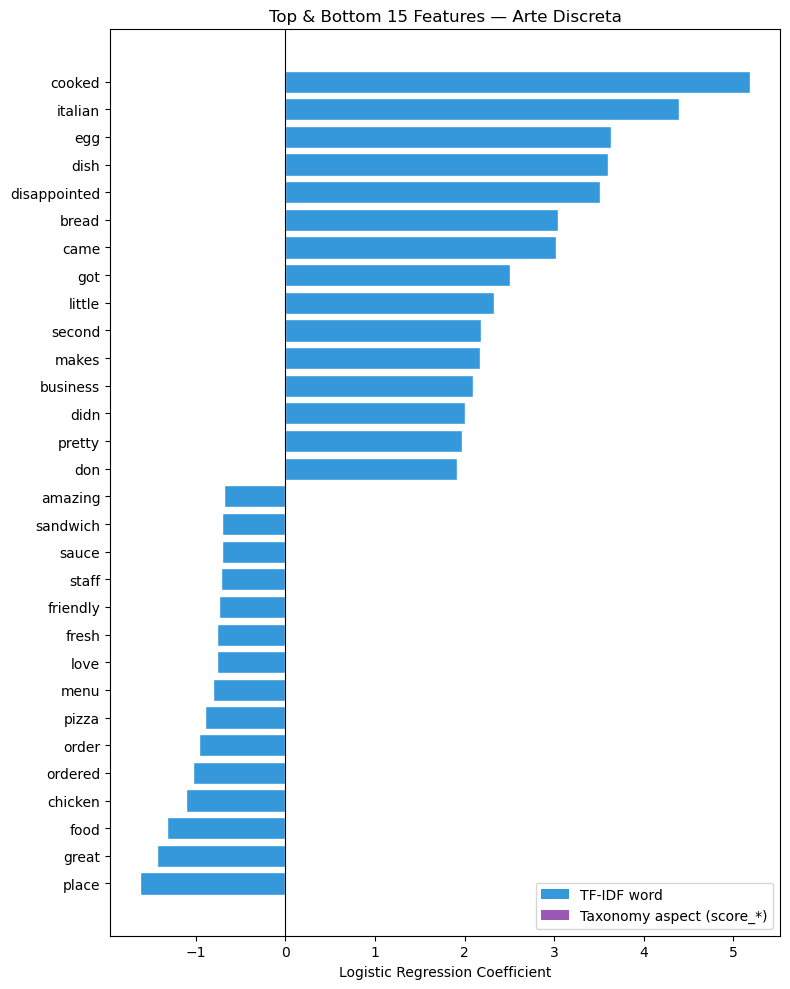

Saved → figures/coefficient_importance.png


In [24]:
# Visualize top/bottom coefficients, highlighting taxonomy features
N = 15
top_n = coef_df.head(N)
bottom_n = coef_df.tail(N)
plot_df = pd.concat([top_n, bottom_n]).reset_index(drop=True)

colors = ['#9b59b6' if f in aspect_cols else '#3498db' for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Top & Bottom 15 Features — Arte Discreta')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='TF-IDF word'),
    Patch(facecolor='#9b59b6', label='Taxonomy aspect (score_*)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('figures/coefficient_importance.png', dpi=150)
plt.show()
print("Saved → figures/coefficient_importance.png")

This is not a defect to explain away. With only two positive examples, 
Logistic Regression did not learn what distinguishes Michelin language 
in general — a known limitation of the method under severe rare-event 
imbalance (King & Zeng, 2001) — it located a hyperplane informed almost 
entirely by the two specific review sets in front of it, and the words 
that happened to recur there were ordinary nouns and adjectives, not the 
curated vocabulary of fine dining. The taxonomy's hypothesis — that named 
aspects of luxury would carry the predictive weight — is not validated 
by this experiment. It is, at n=2, untestable: there is not enough 
signal in the data for any hand-built feature, however well-reasoned, to 
compete with 300 TF-IDF dimensions for a model's attention.

The honest conclusion is methodological rather than culinary: this 
project demonstrates a working pipeline — data, labeling, features, 
evaluation, two metrics — built correctly and validated against its own 
constraints. What it does not demonstrate, and could not have, is that 
luxury hospitality language is identifiable from two examples. That 
question remains open, and would require either substantially more 
positive examples or a fundamentally different evaluation design — 
perhaps treating star-rating tiers as an ordinal target across a larger 
restaurant set, rather than a near-impossible binary search for two 
needles in 8,816 hay.

## 9. Results and Discussion

Taken together, the four models and two metrics tell one coherent story 
from several angles, not four separate ones.

**By ROC-AUC**, Logistic Regression and SVC rank Michelin restaurants 
correctly far more often than chance (0.981 and 0.984), while Random 
Forest and Gradient Boosting sit at the baseline (0.493 and 0.499) — the 
arithmetic consequence of one positive example per training fold, 
explained in 7.2.

**By PR-AUC**, the picture sharpens rather than contradicts: even the 
best model's precision-recall trade-off collapses to 0.016 (SVC) and 
0.012 (Logistic Regression) once the metric stops rewarding correct 
ranking of the 8,814 obvious negatives and asks instead what happens at 
the sharp end, where a real system would have to act. Under a positive 
rate of 0.02%, this gap between the two metrics is not a contradiction — 
it is what extreme imbalance does to evaluation. ROC-AUC says the model 
can rank; PR-AUC says it cannot yet be trusted to decide.

**By coefficient interpretation**, Section 8 showed the gap is not 
cosmetic: the hand-built taxonomy — the project's central hypothesis — 
ranked last among 305 features, while ordinary TF-IDF words dominated. 
The model that "worked" by ROC-AUC did not learn what the taxonomy 
predicted it would learn.

The honest synthesis: this project succeeded as a pipeline — correct 
labeling under severe leakage constraints, correct evaluation strategy 
for n=2, two complementary metrics rather than one flattering one, and a 
model whose coefficients were actually inspected rather than trusted 
blind. It did not succeed as a test of the luxury-taxonomy hypothesis, 
because two positive examples cannot test any hypothesis with confidence. 
Those are different claims, and conflating them would be the real 
methodological error — not the failure to find signal in too little data.

## 10. Conclusions

Let's be honest about what we actually found, because the honest answer 
is stranger and more interesting than the tidy one. We did not discover 
that luxury has a vocabulary. We went looking — built a taxonomy out of 
fifteen years of tasting-menu adjectives, "exquisite" and "sommelier" and 
"once in a lifetime" — and the model shrugged. Ranked dead last, all five 
aspects, buried under "place" and "great" and the word "cooked," of all 
things. Two restaurants is not a sample. It is barely a rumor. And a 
rumor, however well-dressed in mathematics, cannot carry the weight of a 
hypothesis.

So what *did* we build? Something quieter, and maybe more honest: a way of 
asking the question correctly, even when the data refuses to answer it. 
Stratified folds that don't pretend two stars are twenty. A second metric 
— PR-AUC — that exists precisely because the first one lies a little when 
the world is this lopsided. A model we actually opened up and 
interrogated, rather than one we simply trusted because the number looked 
good. That restraint is not a consolation prize. It is the whole point. 
Anyone can find a pattern in two examples; finding one, then admitting it 
might be noise wearing a costume, takes something closer to integrity.

What we carry forward, then, is not a conclusion but an appetite — the 
shape of a better question. Two positive examples will never be enough, 
no matter how cleverly the features are engineered around them; that's 
not a bug to patch, it's a wall, and the only way past a wall like that is 
more data, or a different door entirely. The Deep Learning module waiting 
on the other side of this course offers both. Pretrained embeddings 
already know things about language that a hand-typed list of synonyms 
never could. Larger corpora make "rare" something other than a euphemism 
for "untestable." This was the first movement — careful, classical, 
unhurried, willing to fail cleanly rather than succeed by accident. 
Whatever comes next doesn't inherit our answer. It inherits our 
unfinished question, which is, in the end, the more valuable thing to 
hand off.

## 11. References

**Data**

Yelp, Inc. (2024). *Yelp Open Dataset*. Retrieved from https://www.yelp.com/dataset.

**Michelin recognitions** (facts cited in Section 4.2, "Why 8 Becomes 2")

Restaurant names, cities, star counts, and years of recognition for the 
eight Philadelphia and Tampa establishments referenced are drawn from 
official Michelin Guide ceremony announcements (2023–2025), publicly 
reported by the Michelin Guide at guide.michelin.com.

**Methodology**

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more 
informative than the ROC plot when evaluating binary classifiers on 
imbalanced datasets. *PLOS ONE*, *10*(3), e0118432. 
https://doi.org/10.1371/journal.pone.0118432

King, G., & Zeng, L. (2001). Logistic regression in rare events data. *Political Analysis, 9*(2), 137–163. https://doi.org/10.1093/oxfordjournals.pan.a004868

**Software**

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., 
Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine learning in 
Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

McKinney, W. (2010). Data structures for statistical computing in Python. 
*Proceedings of the 9th Python in Science Conference*, 56–61.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing 
in Science & Engineering*, *9*(3), 90–95.

Cannon, M. (rapidfuzz). *RapidFuzz: Rapid fuzzy string matching for 
Python*. https://github.com/rapidfuzz/RapidFuzz

## Acknowledgements

This project was designed and executed by Avgustina Daskalova. AI coding 
assistance: Claude Sonnet 4.6 (Anthropic, 2026). All code reviewed, 
tested, and validated by the author.